In [1]:
import pandas as pd

from utils import *

df = pd.read_csv("Experiment/3_hTERT_HME1_mutants_comparison/Data/Processed/Mutant_cell_lines_test.tsv", sep="\t")
df

,protein_Id,protein_name,description,Peptide_Sequence,Modified_Sequence,site_start,site_end,Peptide_Length,Charges,Assigned_Modifications,...,WT_log2:FC_EGF_10,WT_log2:FC_EGF_25,BRAFS151A_log2:FC_EGF_starve,BRAFS151A_log2:FC_EGF_2,BRAFS151A_log2:FC_EGF_10,BRAFS151A_log2:FC_EGF_25,GAB1Y259A_log2:FC_EGF_starve,GAB1Y259A_log2:FC_EGF_2,GAB1Y259A_log2:FC_EGF_10,GAB1Y259A_log2:FC_EGF_25
0,P0CG40,SP9,Transcription factor Sp9,AAAAAAAAAAAAAAAASAGGKEAASGPNDS,AAAAAAAAAAAAAAAASAGGKEAAS[79.9663]GPNDS[79.9663],455,484,30,2,"25S(79.9663),30S(79.9663)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P0CG40,SP9,Transcription factor Sp9,AAAAAAAAAAAAAAAASAGGK,AAAAAAAAAAAAAAAAS[79.9663]AGGK,455,475,21,2,17S(79.9663),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,P0CG40,SP9,Transcription factor Sp9,AAAAAAAAAAAAAAAASAGGKEAASGPNDS,AAAAAAAAAAAAAAAAS[79.9663]AGGKEAAS[79.9663]GPNDS,455,484,30,2,"17S(79.9663),25S(79.9663)",...,NaN,NaN,0.0,NaN,1.888218,NaN,0.0,2.985974,NaN,2.937885
3,Q8WXD9,CASKIN1,Caskin-1,AAAAAAAAAAAPPAPPEGASPGDSARQK,AAAAAAAAAAAPPAPPEGASPGDSARQK,1345,1372,28,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Q8WXD9,CASKIN1,Caskin-1,AAAAAAAAAAAPPAPPEGASPGDSAR,AAAAAAAAAAAPPAPPEGAS[79.9663]PGDS[79.9663]AR,1345,1370,26,2,"20S(79.9663),24S(79.9663)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175084,P55735,SEC13,Protein SEC13 homolog,VSVINTVDTSHEDMIHDAQMDYYGTR,n[42.0106]VSVINTVDTSHEDM[15.9949]IHDAQMDYYGTR,2,27,26,3,"N-term(42.0106),14M(15.9949)",...,0.444736,0.413445,0.0,-1.338201,-1.002712,-1.289534,0.0,-0.961074,-0.582581,-0.980391
175085,P55735,SEC13,Protein SEC13 homolog,VSVINTVDTSHEDMIHDAQMDYYGTR,n[42.0106]VSVINTVDTSHEDM[15.9949]IHDAQM[15.994...,2,27,26,3,"N-term(42.0106),14M(15.9949),20M(15.9949)",...,NaN,NaN,0.0,0.170052,NaN,NaN,0.0,0.063073,0.151763,-0.751698
175086,rev_Q17R98,rev_ZNF827,Zinc finger protein 827,WQGSNLGGTPVTHCK,n[42.0106]WQGSNLGGTPVTHC[57.0215]K,2,16,15,2,"N-term(42.0106),14C(57.0215)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
175087,Q9NRJ4,TULP4,Tubby-related protein 4,YAAVEHGPVLCSDSNILCLSWK,n[42.0106]YAAVEHGPVLC[57.0215]S[79.9663]DSNILC...,2,23,22,2,"N-term(42.0106),11C(57.0215),12S(79.9663),18C(...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Filtering data

In [2]:
# Remove rows without PTM
df_filtered = df[df.Assigned_Modifications_clean.notna()]
print(f"Original size: {df.shape}")

# Drop rows where site is not detected in the starvation control
df_filtered = df_filtered[df_filtered["WT_raw:abs_EGF_starve_r1"] != 0]
df_filtered = df_filtered[df_filtered["BRAFS151A_raw:abs_EGF_starve_r1"] != 0]
df_filtered = df_filtered[df_filtered["GAB1Y259A_raw:abs_EGF_starve_r1"] != 0]

raw_columns = [element for element in df.columns if 'raw' in element]

print(f"Dataframe after removing sites with no starve detected: {df_filtered.shape}")
replicates = [element for element in raw_columns if "starve" not in element]
# print(f"Raw columns of time points replicates: {replicates}")

replicates = list(set([element.replace("_r1", "").replace("_r2", "") for element in replicates]))

suffixes = ["_r1", "_r2"]

# Drop rows if the phosphosite was not detected in the 2 replicates for any time point and any condition
for condition in replicates:
    mask = (
        (df_filtered[f"{condition}{suffixes[0]}"] == 0) &
        (df_filtered[f"{condition}{suffixes[1]}"] == 0)
    )
    df_filtered = df_filtered.drop(df_filtered[mask].index)

print(f"Dataframe after removing sites where a site is missing in the two replivates: {df_filtered.shape}")

df_filtered = filter_dynamics_extremes_mutants(df = df_filtered,
                                       data_type="log2:FC",
                                       threshold=0.5,
                                       exclude_full = False,
                                       conditions = ["_EGF_"],
                                       cell_lines = ["WT", "BRAFS151A", "GAB1Y259A"],)
print(f"Dataframe after selecting log2:FC > 0.5: {df_filtered.shape}")

Original size: (175089, 136)
Dataframe after removing sites with no starve detected: (13474, 136)
Dataframe after removing sites where a site is missing in the two replivates: (10885, 136)
Dataframe after selecting log2:FC > 0.5: (9561, 136)


# Clustering based on WT

In [55]:
cluster_name = "testing_clustering"
kmeans_clustered, clustering, multivariate = tslearn_clustering_KMeans_mutants(df_to_cluster= df_filtered,
                                                 data_type= "log2:FC",
                                                 cell_lines = ["WT", "BRAFS151A", "GAB1Y259A"],
                                                 condition_for_clustering=["_EGF_"],
                                                 exclude_full=True,
                                                 cluster_column_name=cluster_name,
                                                 number_of_clusters=15, #25
                                                 max_iterations=100,
                                                 metric="euclidean",
                                                 df_dimensions=3,
                                                 time_series_length=4,
                                                 transpose = True, #data size is (ns, sz, d)
                                                 verbose=True,
                                                 testing = True,
                                                 barycenter_calculations= False)

(9561, 137)
Column selection: ['WT_log2:FC_EGF_starve', 'WT_log2:FC_EGF_2', 'WT_log2:FC_EGF_10', 'WT_log2:FC_EGF_25', 'BRAFS151A_log2:FC_EGF_starve', 'BRAFS151A_log2:FC_EGF_2', 'BRAFS151A_log2:FC_EGF_10', 'BRAFS151A_log2:FC_EGF_25', 'GAB1Y259A_log2:FC_EGF_starve', 'GAB1Y259A_log2:FC_EGF_2', 'GAB1Y259A_log2:FC_EGF_10', 'GAB1Y259A_log2:FC_EGF_25']

Reshaping dataframe to shape (9561, 4, 3)

The size of the dataset is (9561, 4, 3)
Example:
[[ 0.          0.          0.        ]
 [-0.09866993  0.88832203 -0.95591811]
 [-0.80844889  0.80315561  0.01617743]
 [-0.17997857  0.13015663  0.1793945 ]]
Init 1
3.785 --> 3.097 --> 2.985 --> 2.951 --> 2.934 --> 2.919 --> 2.909 --> 2.900 --> 2.892 --> 2.885 --> 2.880 --> 2.877 --> 2.874 --> 2.872 --> 2.871 --> 2.869 --> 2.867 --> 2.866 --> 2.864 --> 2.862 --> 2.861 --> 2.860 --> 2.858 --> 2.857 --> 2.856 --> 2.854 --> 2.853 --> 2.853 --> 2.852 --> 2.852 --> 2.851 --> 2.851 --> 2.851 --> 2.851 --> 2.851 --> 2.851 --> 2.850 --> 2.850 --> 2.850 --> 2.850

## plotting clusters

Exx Plot not saved


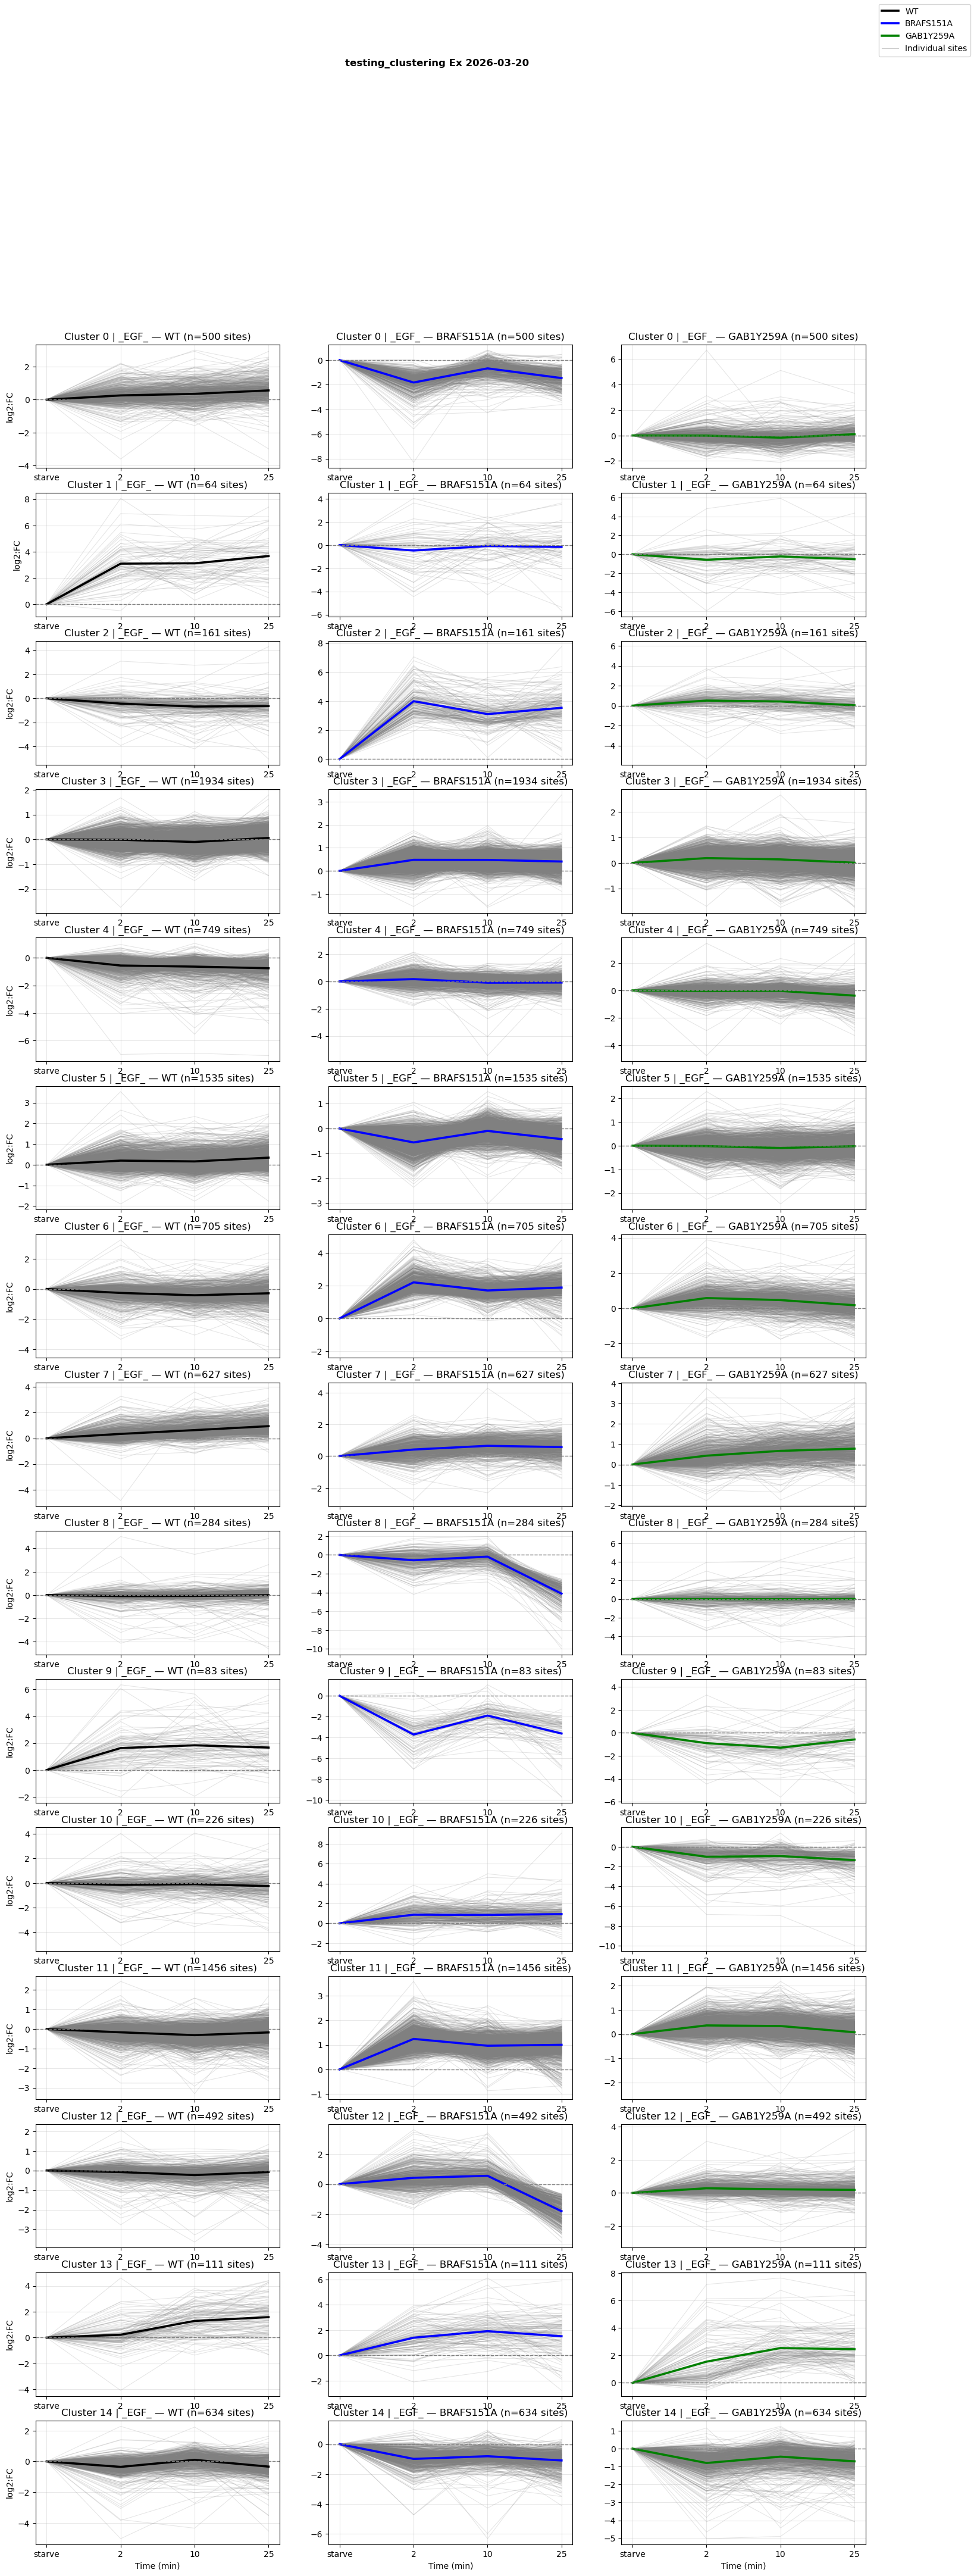

In [56]:
clusters_plot_linear_mutants(
        df = kmeans_clustered,
        legend=["1.57nM EGF", "100nM INS", "1.56nM EGF + 100nM INS"],
        saving_path="",
        cluster_column=cluster_name,
        cluster_name=f"Ex",
        data_type="log2:FC",
        same_cell_lines=False,
        same_condition = True,
        cell_lines= ["WT", "BRAFS151A", "GAB1Y259A"],
        conditions = ["_EGF_"],
        colors={"WT": "black", "BRAFS151A": "blue", "GAB1Y259A": "green"},
        plot_different_data=True,
        saving_info="x",
        save_pdf=False,
        save_png=False,
        plot_close=False,
        y_lims_list=False,
        grey_alpha=0.2,
        grey_lw=0.8,
        mean_lw=2.6
    )

## Check wich proteins are in a cluster

In [57]:
sub_df = kmeans_clustered.loc[kmeans_clustered[cluster_name] == 13]
protein_list = sub_df["protein_name"].unique().tolist()
uniprot_links_for(sub_df, protein_list)

## Check in which clusters a protein appear

In [22]:
protein = "EGFR"
protein_df = kmeans_clustered.loc[kmeans_clustered["protein_name"] == protein]
# protein_df = df.loc[df["protein_name"] == protein]
protein_df[["protein_name", "site", cluster_name]]

,protein_name,site,testing_clustering
29638,EGFR,P00533_687_705_1_1_False_T693,2
46656,EGFR,P00533_109_129_1_0_False_M111,18
49049,EGFR,P00533_1161_1179_1_1_False_Y1172,7
49050,EGFR,P00533_1161_1179_1_1_False_S1166,14
49546,EGFR,P00533_1189_1199_1_1_False_Y1197,7
89746,EGFR,P00533_987_999_1_1_False_S991,10


## plotting all sites of a protein

Plotting sites of protein: AHNAK2


/Users/ignacionavascamacho/PycharmProjects/TMT_Data_analysis/utils.py:2880: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


AHNAK2_Q8IVF2_log2:FC_ — plot not saved


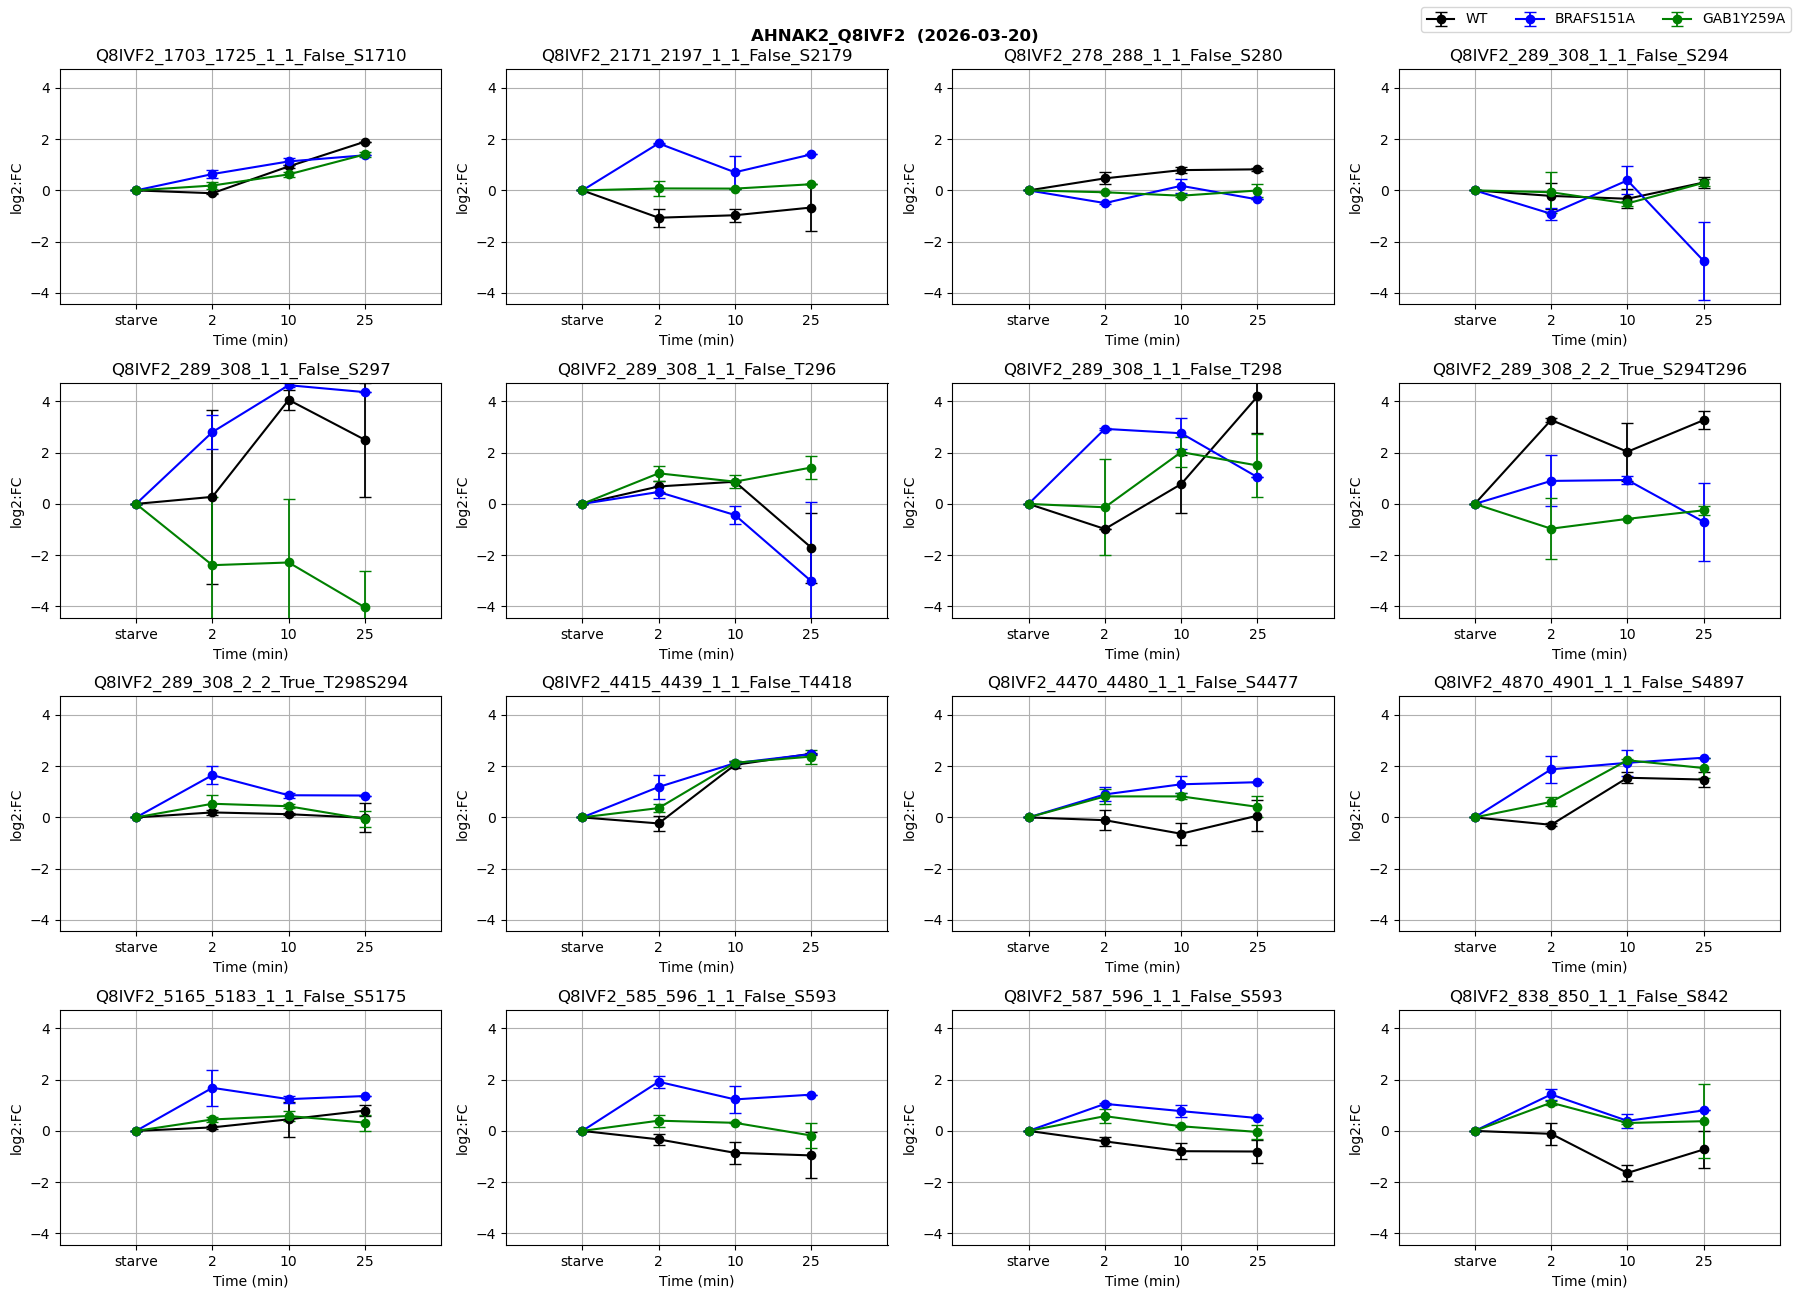

In [59]:
plot_mutants_protein_phosphosites(df = kmeans_clustered,
                                   proteins=["AHNAK2"],
                                   data_type= "log2:FC",
                                   saving_path = "",
                                   legend_plot=["WT", "BRAFS151A", "GAB1Y259A"],
                                   cell_lines = ["WT", "BRAFS151A", "GAB1Y259A"],
                                   conditions = ["_EGF_"],
                                   color_palette = {"WT" : "black",
                                                 "BRAFS151A" : "blue",
                                                 "GAB1Y259A" : "green"},
                                   fit_y_lims= False
                     )